#### analyze the memory capacity of the networks with fixed sequences and LoRA

In [35]:
# simulation: 46
# seed: 2222
seed = 2222

In [36]:
import torch.nn as nn
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sf_workingdir_lilly.dmlab.analysis.custom_esn_analysis import get_time_of_norm_threshold_crossing_fixed_sequence, len_new_orth_vec, len_new_orth_vec_new_not_norm



In [37]:
spec_rad = 1.4
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
#trial=6
fixed_whh=True
fixed_wih=True

expanded_length = Hippo_R + Hippo_L - 1
hidden_size = Hippo_n_feature * expanded_length

x_vals = np.arange(1,70)

seeds = [2222, 3333, 4444, 5555]

In [38]:
# get the network weights
# Create fixed weight matrices.
# weight_ih: shape (hidden_size, n_feature)
W_ih = torch.zeros(hidden_size, Hippo_n_feature)
for i in range(Hippo_n_feature):
    for j in range(Hippo_R):
        row = i * expanded_length + j
        W_ih[row, i] = 1.
# weight_hh: shape (hidden_size, hidden_size)
W_hh_base = torch.zeros(hidden_size, hidden_size)
for i in range(Hippo_n_feature):
    for j in range(1, expanded_length):
        row = i * expanded_length + j
        col = i * expanded_length + (j - 1)
        W_hh_base[row, col] = 1.0

In [39]:
# add the lora component
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim46_lora.pkl", "rb") as f:
    trained_lora = pickle.load(f)

lr_column = trained_lora[seed]['lr_column']
lr_row = trained_lora[seed]['lr_row']

W_hh_2222 = W_hh_base + lr_column @ lr_row

lr_column = trained_lora[3333]['lr_column']
lr_row = trained_lora[3333]['lr_row']

W_hh_3333 = W_hh_base + lr_column @ lr_row

lr_column = trained_lora[4444]['lr_column']
lr_row = trained_lora[4444]['lr_row']

W_hh_4444 = W_hh_base + lr_column @ lr_row

lr_column = trained_lora[5555]['lr_column']
lr_row = trained_lora[5555]['lr_row']

W_hh_5555 = W_hh_base + lr_column @ lr_row

In [40]:
W_hh = [W_hh_2222, W_hh_3333, W_hh_4444, W_hh_5555]

In [41]:
# create the hidden states, input at the first time step and then zero inputs for the rest of the time steps
def get_hidden_states(W_ih, W_hh):
    rnn = nn.RNN(input_size=Hippo_n_feature, 
                        hidden_size=hidden_size,
                        num_layers=1, 
                        nonlinearity='relu',
                        batch_first=False,
                        bias=False)

    # fix the rnn weights
    W_ih = W_ih.detach()
    W_hh = W_hh.detach()
    W_ih = W_ih.to(rnn.weight_ih_l0.device, dtype=rnn.weight_ih_l0.dtype)
    W_hh = W_hh.to(rnn.weight_hh_l0.device, dtype=rnn.weight_hh_l0.dtype)
    with torch.no_grad():
        rnn.weight_ih_l0.copy_(W_ih)
        rnn.weight_hh_l0.copy_(W_hh)
    # Freeze RNN parameters.
    for param in rnn.parameters():
        param.requires_grad = False
    # create output vector (time steps x hidden size)
    hs = torch.zeros(time_steps, hidden_size)
    # first input
    u = torch.zeros(1,1,Hippo_n_feature) # shape: (1, B, n_feature)
    # u[:,0,0] = 1.0
    u[:,:,0] = 1.0
    h0 = torch.zeros(1,1,hidden_size)
    y, h = rnn.forward(u, h0)
    hs[0,:] = h
    # zero inputs for the amount of time steps
    for i in range(1, time_steps):
        u = torch.zeros(1,1,Hippo_n_feature)
        y, h = rnn.forward(u, h)
        # update the output vector: update the row corresponding to the current time step
        hs[i,:] = h
        i += 1
    return hs

hs_2222 = get_hidden_states(W_ih, W_hh_2222)
hs_3333 = get_hidden_states(W_ih, W_hh_3333)
hs_4444 = get_hidden_states(W_ih, W_hh_4444)
hs_5555 = get_hidden_states(W_ih, W_hh_5555)

hs = [hs_2222, hs_3333, hs_4444, hs_5555]

#### Norm

In [42]:
neuron_norms_for_srs_2222 = hs_2222.norm(dim=1)
neuron_norms_for_srs_3333 = hs_3333.norm(dim=1)
neuron_norms_for_srs_4444 = hs_4444.norm(dim=1)
neuron_norms_for_srs_5555 = hs_5555.norm(dim=1)

In [43]:
thresh_crossed_2222 = get_time_of_norm_threshold_crossing_fixed_sequence(neuron_norms_for_srs_2222, threshold=0.1)
thresh_crossed_3333 = get_time_of_norm_threshold_crossing_fixed_sequence(neuron_norms_for_srs_3333, threshold=0.1)
thresh_crossed_4444 = get_time_of_norm_threshold_crossing_fixed_sequence(neuron_norms_for_srs_4444, threshold=0.1)
thresh_crossed_5555 = get_time_of_norm_threshold_crossing_fixed_sequence(neuron_norms_for_srs_5555, threshold=0.1)

tresh_crossed_norms = [thresh_crossed_2222, thresh_crossed_3333, thresh_crossed_4444, thresh_crossed_5555]

thresh  tensor(0.2828)
thresh  tensor(0.2828)
thresh  tensor(0.2828)
thresh  tensor(0.2828)


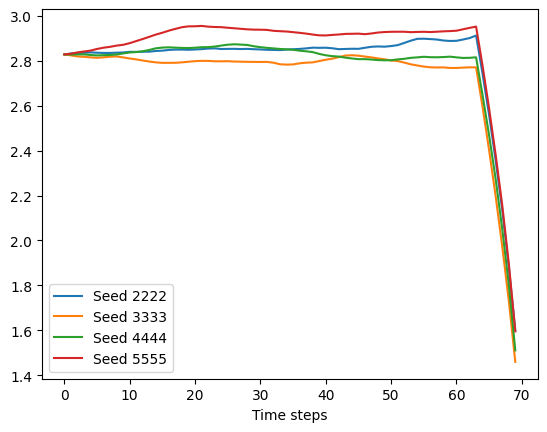

In [44]:
x_vals = np.arange(1,70)
plt.figure()
#for i in range(Hippo_n_feature):
plt.plot(neuron_norms_for_srs_2222, label='Seed 2222')
plt.plot(neuron_norms_for_srs_3333, label='Seed 3333')
plt.plot(neuron_norms_for_srs_4444, label='Seed 4444')
plt.plot(neuron_norms_for_srs_5555, label='Seed 5555')
plt.xlabel('Time steps')
plt.legend()


#### orthogonal vector

In [45]:
# get the orthogonal vector not normalized
try:
    len_orth_vectors_2222 = len_new_orth_vec(hs_2222, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

try:
    len_orth_vectors_3333 = len_new_orth_vec(hs_3333, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')        

try:   
    len_orth_vectors_4444 = len_new_orth_vec(hs_4444, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

try:
    len_orth_vectors_5555 = len_new_orth_vec(hs_5555, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

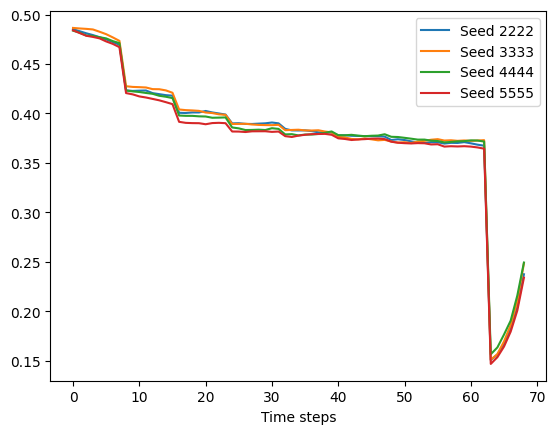

In [46]:
x_vals = np.arange(1,70)
plt.figure()
#for i in range(Hippo_n_feature):
plt.plot(len_orth_vectors_2222, label='Seed 2222')
plt.plot(len_orth_vectors_3333, label='Seed 3333')
plt.plot(len_orth_vectors_4444, label='Seed 4444')
plt.plot(len_orth_vectors_5555, label='Seed 5555')
plt.xlabel('Time steps')
plt.legend()

In [47]:
# get the threshold crossing
orth_thresh_crossed_2222 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_2222, threshold=0.1)
orth_thresh_crossed_3333 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_3333, threshold=0.1)
orth_thresh_crossed_4444 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_4444, threshold=0.1)
orth_thresh_crossed_5555 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_5555, threshold=0.1)

orth_thresh_crossed = [orth_thresh_crossed_2222, orth_thresh_crossed_3333, orth_thresh_crossed_4444, orth_thresh_crossed_5555]

thresh  0.048524323105812076
thresh  0.04864850640296936
thresh  0.04837180376052857
thresh  0.04841209948062897


#### orthogonal vector not norm

In [48]:
# get the orthogonal vector not normalized
try:
    len_orth_vectors_not_norm_2222 = len_new_orth_vec_new_not_norm(hs_2222, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

try:
    len_orth_vectors_not_norm_3333 = len_new_orth_vec_new_not_norm(hs_3333, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')        

try:   
    len_orth_vectors_not_norm_4444 = len_new_orth_vec_new_not_norm(hs_4444, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

try:
    len_orth_vectors_not_norm_5555 = len_new_orth_vec_new_not_norm(hs_5555, time_steps)
except Exception as e:
    print(f'Could not compute length of orthogonal vectors')

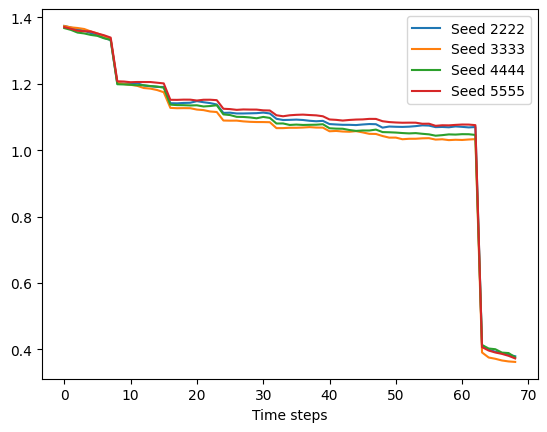

In [49]:
x_vals = np.arange(1,70)
plt.figure()
#for i in range(Hippo_n_feature):
plt.plot(len_orth_vectors_not_norm_2222, label='Seed 2222')
plt.plot(len_orth_vectors_not_norm_3333, label='Seed 3333')
plt.plot(len_orth_vectors_not_norm_4444, label='Seed 4444')
plt.plot(len_orth_vectors_not_norm_5555, label='Seed 5555')
plt.xlabel('Time steps')
plt.legend()

In [50]:
# get the threshold crossing
orth_not_norm_thresh_crossed_2222 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_2222, threshold=0.1)
orth_not_norm_thresh_crossed_3333 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_3333, threshold=0.1)
orth_not_norm_thresh_crossed_4444 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_4444, threshold=0.1)
orth_not_norm_thresh_crossed_5555 = get_time_of_norm_threshold_crossing_fixed_sequence(len_orth_vectors_not_norm_5555, threshold=0.1)

orth_not_norm_thresh_crossed = [orth_not_norm_thresh_crossed_2222, orth_not_norm_thresh_crossed_3333, orth_not_norm_thresh_crossed_4444, orth_not_norm_thresh_crossed_5555]

thresh  0.13744056224822998
thresh  0.13739598989486695
thresh  0.13678336143493652
thresh  0.13708076477050782


#### after Memory of Recurrent Networks: Do We Compute It Right? (Giovanni et al., 2024)

In [51]:
# 1) construct the Krylov matrix
def construct_krylov_matrix(whh, wih, time_steps):
    # C: w_ih, A: w_hh
    C, A = wih, whh
    K = torch.zeros((C.shape[0], time_steps))
    # input 
    u = torch.zeros(Hippo_n_feature)
    u[0] = 1.0
    # create a varaibel, so that the power of A does not need to be computed each time
    current_A = torch.linalg.matrix_power(A, 0)
    # C @ input
    C = C @ u
    for t in range(time_steps):
        col = current_A @ C 
        current_A = current_A @ A
        K[:, t] = col  
    return K

def compute_mc(whh, wih, time_steps):
    K = construct_krylov_matrix(whh, wih, time_steps)
    U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)

    tol = S.max() * max(K.shape) * torch.finfo(S.dtype).eps
    k = int((S > tol).sum().item())
    #print("effective k:", k)  

    # threshold the singular values
    Vh_k = Vh[:k, :]           # (k, m)
    P = Vh_k.T @ Vh_k          # (m, m) projector onto row-space
    MC = torch.diag(P)         # (m,) 
    return MC

In [52]:
MC_mode_2222 = compute_mc(W_hh_2222, W_ih, time_steps)
MC_mode_3333 = compute_mc(W_hh_3333, W_ih, time_steps)
MC_mode_4444 = compute_mc(W_hh_4444, W_ih, time_steps)
MC_mode_5555 = compute_mc(W_hh_5555, W_ih, time_steps)

MC_sum_2222 = MC_mode_2222.sum().item()
MC_sum_3333 = MC_mode_3333.sum().item()
MC_sum_4444 = MC_mode_4444.sum().item()
MC_sum_5555 = MC_mode_5555.sum().item()

MC_sum = [MC_sum_2222, MC_sum_3333, MC_sum_4444, MC_sum_5555]

/tmp/ipykernel_2150649/3793484771.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)


#### Xiaos' method SVD - singular value threshold

In [53]:
def compute_mc_svd_variance(whh, wih, time_steps, threshold=0.98):
    K = construct_krylov_matrix(whh, wih, time_steps) 
    U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)

    total_variance = (S**2).sum().item()
    # why squared singular values? because variance along each principal component is given by the square of the singular value
    variance_cumsum = torch.cumsum(S**2, dim=0)

    num_singular_values = 1
    i = 0
    while variance_cumsum[i] <= threshold * total_variance:
        num_singular_values += 1
        i += 1

    return num_singular_values

In [54]:
MC_singular_components = []
for i, seed in enumerate(seeds):
    current_MC = compute_mc_svd_variance(W_hh[i], W_ih, time_steps)
    MC_singular_components.append(current_MC)

/tmp/ipykernel_2150649/1271892696.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U, S, Vh = torch.linalg.svd(torch.tensor(K), full_matrices=False)


#### singular value threshold but with the hidden states, so the nonlinearity is included

In [55]:
def compute_svd_variance_hs(hid_state, seed_idx, time_steps, threshold=0.98):
    #hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=0)  # (time_steps, hidden_size)
    current_hs = hid_state[seed_idx]
    U, S, Vh = torch.linalg.svd(torch.tensor(current_hs.T), full_matrices=False)

    total_variance = (S**2).sum().item()
    variance_cumsum = torch.cumsum(S**2, dim=0)
    num_singular_values = 1
    i = 0
    while variance_cumsum[i] <= threshold * total_variance:
        num_singular_values += 1
        i += 1

    return num_singular_values

In [56]:
MC_singular_components_hs = []
for i, seed in enumerate(seeds):
    current_hs_MC = compute_svd_variance_hs(hs, i, time_steps, threshold=0.98)
    MC_singular_components_hs.append(current_hs_MC)


/tmp/ipykernel_2150649/2804525668.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U, S, Vh = torch.linalg.svd(torch.tensor(current_hs.T), full_matrices=False)


#### Participation ratio

In [57]:
def compute_participation_ratio(whh, wih, time_steps, threshold=0.98):
    K = construct_krylov_matrix(whh, wih, time_steps) 
    K = K.to(dtype=torch.float64) 
    U, S, Vh = torch.linalg.svd(K, full_matrices=False)
    #S/=1e5
    eig_vals = S**2
    #print("eigenvalues:", eig_vals)
    pr = (eig_vals.sum().item())**2 / (eig_vals**2).sum().item()
    return pr

In [58]:
participation_ratios = []
for i, seed in enumerate(seeds):
    current_pr = compute_participation_ratio(W_hh[i], W_ih, time_steps, threshold=0.98)
    participation_ratios.append(current_pr)

#### save the measures

In [59]:
mc_measures = {'orth_vec_thresh_crossed': orth_thresh_crossed,
               'orth_vec_thresh_crossed_not_norm': orth_not_norm_thresh_crossed,
               'norm_thresh_crossed': tresh_crossed_norms,
               'summed_MC_svd': MC_sum,
               'MC_singular_components_svd': MC_singular_components,
               'MC_singular_components_hs_svd': MC_singular_components_hs,
               'participation_ratio_svd': participation_ratios
               }

In [60]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measureslora46.pkl", "wb") as f:
    pickle.dump(mc_measures, f)